# **G345 - ANÁLISIS DE DATOS**

# **ANÁLISIS DE LA DEPRESIÓN EN ESTUDIANTES Y SUS PREDICTORES**

# **Preparar el Entorno**

In [ ]:
# Se habilita el Drive para la carga de archivos
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Se importan las librerías
import numpy as np
import pandas as pd
import os

import matplotlib.pyplot as plt   # Visualizaciones
import seaborn as sns             # Visualizaciones
import statsmodels.api as sm      # Funciones Modelos Estadísticos

# **Cargar Datos desde un CSV**

### **Acerca de este archivo**

Este conjunto de datos contiene información completa sobre la salud mental y sus factores relacionados, de un conjunto de estudiantes de diferentes niveles académicos en varias ciudades de la India. Está diseñado para analizar **las tendencias y los predictores de la depresión** en estudiantes.

Los datos incluyen información demográfica, presiones académicas y laborales, hábitos de vida e indicadores específicos de salud mental.

Los investigadores pueden utilizar este conjunto de datos para identificar factores de riesgo de depresión y desarrollar estrategias de intervención temprana, garantizando al mismo tiempo el manejo ético de información confidencial.

### **Esquema del CSV: Diccionario de Datos**



**Id:**
Un identificador único asignado a cada registro de estudiante en el conjunto de datos.

**Género:**
El género del estudiante (p. ej., masculino, femenino, otro). Esto ayuda a analizar las tendencias específicas de género en salud mental.

**Edad:**
La edad del estudiante en años.

**Ciudad:**
La ciudad o región donde reside el estudiante, que proporciona el contexto geográfico para el análisis.

**Presión Académica:**
Una medida que indica el nivel de presión que enfrenta el estudiante en el ámbito académico. Esto podría incluir el estrés por exámenes, tareas y expectativas académicas generales.

**Presión Laboral:**
Una medida de la presión relacionada con el trabajo o las responsabilidades laborales, relevante para estudiantes que trabajan mientras estudian.

**Promedio de Calificaciones Acumulativo:**
El promedio de calificaciones acumulativo del estudiante, que refleja su rendimiento académico general.

**Satisfacción con los Estudios:**
Un indicador de la satisfacción del estudiante con sus estudios, que puede correlacionarse con el bienestar mental.

**Satisfacción Laboral:**
Una medida de la satisfacción del estudiante con su trabajo o entorno laboral, si corresponde.

**Duración del Sueño:**
El promedio de horas que el estudiante duerme al día, un factor importante para la salud mental.

**Hábitos Alimenticios:**
Una evaluación de los patrones de alimentación y los hábitos nutricionales del estudiante, que pueden afectar su salud general y estado de ánimo.

**Título:**
El título o programa académico que cursa el estudiante.

**¿Ha tenido alguna vez pensamientos suicidas?:**
Un indicador binario (Sí/No) que refleja si el estudiante alguna vez ha experimentado ideación suicida.

**Horas de trabajo/Estudio:**
El promedio de horas diarias que el estudiante dedica al trabajo o al estudio, lo cual puede influir en sus niveles de estrés.

**Estrés Financiero:**
Una medida del estrés experimentado debido a preocupaciones financieras, que puede afectar la salud mental.

**Antecedentes Familiares de Enfermedades Mentales:**
Indica si existen antecedentes familiares de enfermedades mentales (Sí/No), lo cual puede ser un factor significativo en la predisposición a la salud mental.

**Depresión:**
La variable objetivo que indica si el estudiante experimenta depresión (Sí/No). Este es el enfoque principal del análisis.


### **Archivo CSV**

In [ ]:
# Lectura del archivo .csv

ruta_csv = '/content/drive/MyDrive/Análisis G345/Sesión 17 - Feb 02 Lun/Dataset Preparado.csv'

try:
  df = pd.read_csv(ruta_csv)
except OSError as err:
  print(f"No se pudo abrir el archivo. Error: {err}.")
else:
  print(f"Archivo cargado con éxito en el dataframe.")

No se pudo abrir el archivo. Error: [Errno 2] No such file or directory: '/content/drive/MyDrive/Análisis G345/Sesión 17 - Feb 02 Lun/Dataset Preparado.csv'.


In [ ]:
df.head()

,Género,Edad,Ciudad,Presión Académica,Presión Laboral,Promedio Calificaciones Acumulativo,Satisfacción con el Estudio,Satisfacción Laboral,Duración del Sueño,Hábitos Alimenticios,...,Estrés Financiero,Antecedentes Familiares de Enfermedades Mentales,Depresión,GEN,CIU,DS,HA,TIT,PS,AFEM
0,Masculino,33,Visakhapatnam,5,0,8.97,2,0,5-6 horas,Saludable,...,0,No,1,0,0,1,2,0,1,0
1,Femenino,24,Bangalore,2,0,5.90,5,0,5-6 horas,Moderado,...,1,Si,0,1,1,1,1,1,0,1
2,Masculino,31,Srinagar,3,0,7.03,5,0,Menos de 5 horas,Saludable,...,0,Si,0,0,2,0,2,2,0,1
3,Femenino,28,Varanasi,3,0,5.59,2,0,7-8 horas,Moderado,...,4,Si,1,1,3,2,1,3,1,1
4,Femenino,25,Jaipur,4,0,8.13,3,0,5-6 horas,Moderado,...,0,No,0,1,4,1,1,4,1,0




---



---


#**Análisis Univariado**

## **Estadísticas Descriptivas**

Las estadísticas descriptivas permiten resumir y entender la distribución, tendencia central y dispersión de un conjunto de datos.

*  **Media, mediana** y **moda** describen la **tendencia central**.
*  **Desviación estándar** y **varianza** miden **dispersión**.
*  **Asimetría** y **curtosis** revelan la **forma de la distribución**.
*  **Percentiles** ayudan a entender **posiciones relativas** (ej: outliers).

### **Función .describe()**

Muestra un resúmen de las estadísticas descriptivas del DataFrame para las variables numéricas. Se puede redondear al número deseado de decimales.

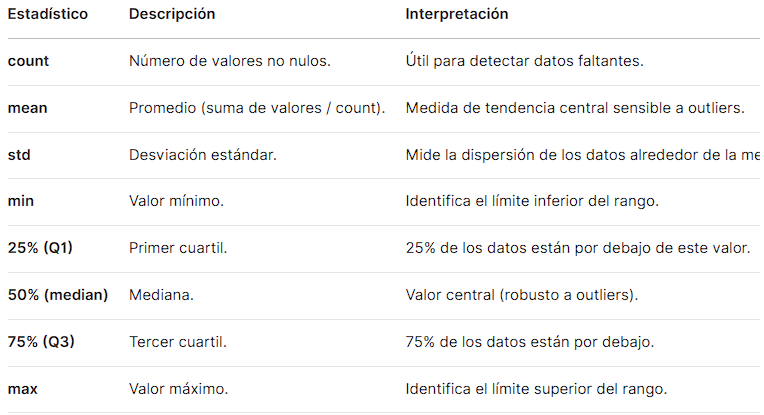

In [ ]:
df.describe().round(2)

,Edad,Presión Académica,Presión Laboral,Promedio Calificaciones Acumulativo,Satisfacción con el Estudio,Satisfacción Laboral,Horas de Trabajo,Estrés Financiero,Depresión,GEN,CIU,DS,HA,TIT,PS,AFEM
count,27880.00,27880.00,27880.00,27880.00,27880.00,27880.00,27880.00,27880.00,27880.00,27880.00,27880.00,27880.00,27880.00,27880.00,27880.00,27880.00
mean,25.82,3.14,0.00,7.66,2.94,0.00,7.16,2.14,0.59,0.44,14.34,1.40,0.91,10.86,0.63,0.48
std,4.91,1.38,0.04,1.47,1.36,0.04,3.71,1.44,0.49,0.50,8.56,1.13,0.80,6.99,0.48,0.50
min,18.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,21.00,2.00,0.00,6.29,2.00,0.00,4.00,1.00,0.00,0.00,7.00,0.00,0.00,6.00,0.00,0.00
50%,25.00,3.00,0.00,7.77,3.00,0.00,8.00,2.00,1.00,0.00,14.00,1.00,1.00,9.00,1.00,0.00
75%,30.00,4.00,0.00,8.92,4.00,0.00,10.00,3.00,1.00,1.00,22.00,2.00,2.00,16.00,1.00,1.00
max,59.00,5.00,5.00,10.00,5.00,4.00,12.00,4.00,1.00,1.00,44.00,3.00,3.00,28.00,1.00,1.00


### **Mínimo y Máximo**

**Definición**

*  **Mínimo (min):** El valor más pequeño en un conjunto de datos.
*  **Máximo (max):** El valor más grande en un conjunto de datos.

**Interpretación:**

*  Identifican el **rango** de los datos (rango = máximo - mínimo).
*  Útiles para **detectar errores** (ej: valores negativos en datos que deben ser positivos) o **outliers extremos**.

In [ ]:
# Se calculan los mínimos
df.min()

,0
Género,Femenino
Edad,18
Ciudad,Agra
Presión Académica,0
Presión Laboral,0
Promedio Calificaciones Acumulativo,0.0
Satisfacción con el Estudio,0
Satisfacción Laboral,0
Duración del Sueño,5-6 horas
Hábitos Alimenticios,Moderado


In [ ]:
df.max()

,0
Género,Masculino
Edad,59
Ciudad,Visakhapatnam
Presión Académica,5
Presión Laboral,5
Promedio Calificaciones Acumulativo,10.0
Satisfacción con el Estudio,5
Satisfacción Laboral,4
Duración del Sueño,Más de 8 horas
Hábitos Alimenticios,Saludable


### **Media (Promedio)**

**Definición**

La media aritmética es la suma de todos los valores dividida entre el número de observaciones.

**Fórmula:**

> 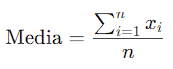

**Interpretación:**

*  **Qué indica:** El valor "típico" o central de un conjunto de datos.

*  **Ventaja:** Fácil de calcular y entender.

*  **Limitación:** Sensible a outliers (valores extremos pueden distorsionarla).

*  **Ejemplo:**

>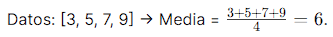

In [ ]:
# Extraigo las columnas numéricas que soportan el cálculo
df_temp = df[['Edad','Promedio Calificaciones Acumulativo','Horas de Trabajo']]

# Se calcula la media
df_temp.mean().round(2)

,0
Edad,25.82
Promedio Calificaciones Acumulativo,7.66
Horas de Trabajo,7.16


### **Mediana**

**Definición**

El valor que divide los datos ordenados en dos partes iguales (50% de los datos están por encima y 50% por debajo).

**Fórmula:**

> 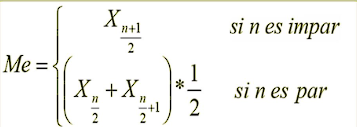

**Interpretación**

*  **Qué indica:** Una medida de tendencia central robusta a outliers.
*  **Cálculo:**
  * Si n es impar: Valor central.
  * Si n es par: Promedio de los dos valores centrales.
*  **Ejemplo:**
>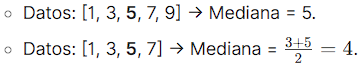

In [ ]:
# Se eliminan temporalmente las columnas categóricas
df_temp = df.drop(['Género', 'Ciudad', 'Duración del Sueño', 'Hábitos Alimenticios', 'Título', 'Pensamientos Suicidas?', 'Antecedentes Familiares de Enfermedades Mentales'], axis=1)

# Se calcula la mediana
df_temp.median().round(2)

,0
Edad,25.00
Presión Académica,3.00
Presión Laboral,0.00
Promedio Calificaciones Acumulativo,7.77
Satisfacción con el Estudio,3.00
Satisfacción Laboral,0.00
Horas de Trabajo,8.00
Estrés Financiero,2.00
Depresión,1.00
GEN,0.00


### **Moda**

**Definición**

El valor que aparece con mayor frecuencia en un conjunto de datos.

**Interpretación**

*  **Qué indica:** El valor más "popular" o común.
*  **Tipos:**
  *  Unimodal: Una moda.
  *  Bimodal/Multimodal: Dos o más modas.
*  **Ejemplo:**
>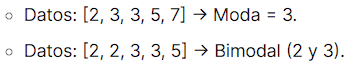

In [ ]:
df.mode()

,Género,Edad,Ciudad,Presión Académica,Presión Laboral,Promedio Calificaciones Acumulativo,Satisfacción con el Estudio,Satisfacción Laboral,Duración del Sueño,Hábitos Alimenticios,...,Estrés Financiero,Antecedentes Familiares de Enfermedades Mentales,Depresión,GEN,CIU,DS,HA,TIT,PS,AFEM
0,Masculino,24,Kalyan,3,0,8.04,4,0,Menos de 5 horas,No Saludable,...,4,No,1,0,11,0,0,6,1,0


In [ ]:
df.mode().iloc[0]

,0
Género,Masculino
Edad,24
Ciudad,Kalyan
Presión Académica,3
Presión Laboral,0
Promedio Calificaciones Acumulativo,8.04
Satisfacción con el Estudio,4
Satisfacción Laboral,0
Duración del Sueño,Menos de 5 horas
Hábitos Alimenticios,No Saludable


### **Desviación Estándar (σ o s)**

**Definición**

Mide la dispersión de los datos alrededor de la media. Utiliza las mismas unidades de los datos.

**Fórmula:**

>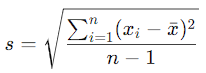

**Interpretación**

*  **Qué indica:**
  *  Alta desviación: Datos muy dispersos.
  *  Baja desviación: Datos cercanos a la media.
*  **Ejemplo:**
>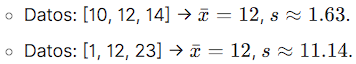


In [ ]:
# Extraigo las columnas numéricas que soportan el cálculo
df_temp = df[['Edad','Promedio Calificaciones Acumulativo','Horas de Trabajo']]

# Se calcula la desviación estándar
df_temp.std().round(3)

### **Varianza (σ² o s²) (std²)**

**Definición**

Es el cuadrado de la desviación estándar. Mide la dispersión en unidades al cuadrado.

**Fórmula:**

>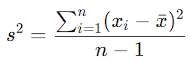

**Interpretación**

*  **Qué indica:** Similar a la desviación estándar, pero en escala diferente.
*  **Diferencia clave:**
  *  La varianza es más útil en cálculos matemáticos (ej: ANOVA).
  *  La desviación estándar es más intuitiva (misma unidad que los datos).


In [ ]:
# Extraigo las columnas numéricas que soportan el cálculo
df_temp = df[['Edad','Promedio Calificaciones Acumulativo','Horas de Trabajo']]

# Se calcula la varianza
df_temp.var().round(3)

### **Coeficiente de Asimetría**

**Definición**

Mide la falta de simetría en la distribución de los datos.

**Interpretación**

*  **Asimetría = 0:** Distribución simétrica (ej: normal).
*  **Asimetría > 0:** Cola a la derecha (sesgo positivo).
*  **Asimetría < 0:** Cola a la izquierda (sesgo negativo).

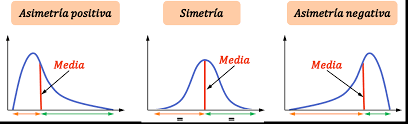

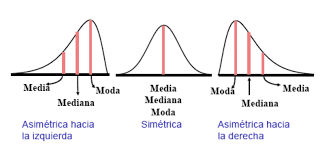


*  **Ejemplo visual:**
>Datos con sesgo positivo: [1, 2, 3, 4, 100] → Media > Mediana.

In [ ]:
# Se eliminan temporalmente las columnas categóricas que ya están representadas en columnas numéricas
df_temp = df.drop(['Género', 'Ciudad', 'Duración del Sueño', 'Hábitos Alimenticios', 'Título', 'Pensamientos Suicidas?', 'Antecedentes Familiares de Enfermedades Mentales'], axis=1)

# Se calcula el coeficiente de asimetría
df_temp.skew().round(3)

### **Curtosis**

**Definición**

Mide el "grado de picudez" o peso de las colas en una distribución, o en otras palabras, qué tan concentrados están los datos alrededor de la media.

**Interpretación**

*  **Curtosis = 0:** Similar a la distribución normal (mesocúrtica).
*  **Curtosis > 0:** Colas pesadas y pico pronunciado (leptocúrtica).
*  **Curtosis < 0:** Colas ligeras y pico aplanado (platicúrtica).

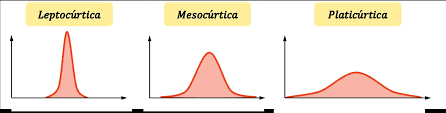

*  **Ejemplo:**
>Datos con alta curtosis: [1, 1, 1, 100, 100, 100] (picos extremos).

In [ ]:
# Se eliminan temporalmente las columnas categóricas que ya están representadas en columnas numéricas
df_temp = df.drop(['Género', 'Ciudad', 'Duración del Sueño', 'Hábitos Alimenticios', 'Título', 'Pensamientos Suicidas?', 'Antecedentes Familiares de Enfermedades Mentales'], axis=1)

# Se calcula la curtosis
df_temp.kurtosis().round(3)

### **Percentiles**

**Definición**

Valores que dividen los datos ordenados en 100 partes iguales.

**Interpretación**

*  **Percentil 50%** = Mediana o Cuartil 2 (Q2)
*  **Percentil 25% (Q1) y 75% (Q3):** Usados en boxplots para calcular IQR.
*  **Ejemplo:**
>Datos: [1, 2, 3, 4, 5] → P25 = 2, P50 = 3, P75 = 4.

In [ ]:
# Se eliminan temporalmente las columnas categóricas que ya están representadas en columnas numéricas
df_temp = df.drop(['Género', 'Ciudad', 'Duración del Sueño', 'Hábitos Alimenticios', 'Título', 'Pensamientos Suicidas?', 'Antecedentes Familiares de Enfermedades Mentales'], axis=1)

# Se calculan los percentiles/cuartiles
df_temp.quantile(0.25).round(3) # Q1

In [ ]:
df_temp.quantile(0.75).round(3) # Q3

### **Resumen**

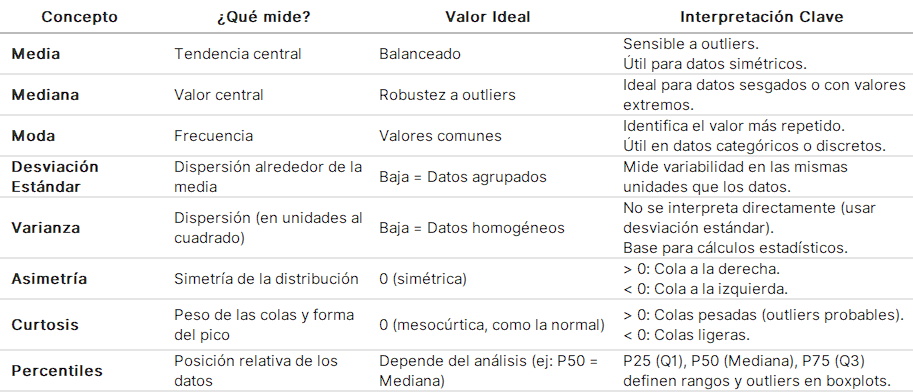

## **Tabla de Frecuencias**

Una tabla de frecuencias es una herramienta estadística que organiza datos categóricos o numéricos en categorías (intervalos o valores únicos) y muestra cuántas veces aparece cada categoría en un conjunto de datos. Es fundamental para resumir y analizar distribuciones de datos.

**Componentes Básicos**

Una tabla de frecuencias típica incluye:

*  **Categorías (Clases):** Valores únicos o intervalos de la variable analizada.
*  **Frecuencia Absoluta (fi):** Número de veces que aparece cada categoría.
*  **Frecuencia Relativa (fri):** Proporción respecto al total (en porcentaje o decimal).
*  **Frecuencia Acumulada (Fi):** Suma progresiva de frecuencias absolutas o relativas.

### **Para Frecuencias Simples (value_counts())**

**Parámetros clave:**
*  **normalize=True:** Calcula proporciones (frecuencias relativas).
*  **ascending=True:** Orden ascendente.
*  **dropna=False:** Incluye conteo de valores nulos.

In [ ]:
# Una sola columna

# Frecuencia Absoluta
frecuencia_genero = df['Género'].value_counts()
print(frecuencia_genero)

In [ ]:
# Frecuencia Relativa
frecuencia_genero_pct = df['Género'].value_counts(normalize=True).mul(100).round(1)
# normalize=True: Convierte los conteos a proporciones (fracciones de 1) en lugar de conteos absolutos
# mul(100): Multiplica todas las proporciones por 100 para convertirlas a porcentajes
print(frecuencia_genero_pct)

In [ ]:
# Concatenar por columnas
tabla = pd.concat([frecuencia_genero, frecuencia_genero_pct], axis=1)
tabla.columns = ['Frecuencia Absoluta', 'Frecuencia Relativa']
tabla

In [ ]:
# Usando join (si las Series tienen el mismo índice)
tabla1 = frecuencia_genero.to_frame().join(frecuencia_genero_pct)
tabla1.columns = ['Frecuencia Absoluta', 'Frecuencia Relativa']
tabla1

In [ ]:
df.columns

In [ ]:
# Frecuencia ordenada por el índice de la tabla de frecuencia
for col in df.columns:
    print(f"\nFrecuencia para {col}:")
    print(df[col].value_counts().sort_index())

### Ordenar por un orden personalizado

Si necesitas un orden específico para las categorías (por ejemplo, 'Femenino' antes que 'Masculino' por alguna razón), puedes definir ese orden y luego aplicar un tipo de dato `Categorical`.

In [ ]:
df['Duración del Sueño'].unique()

In [ ]:
# 1. Define tu orden personalizado
orden_personalizado = ['Menos de 5 horas', '5-6 horas', '7-8 horas', 'Más de 8 horas']

# 2. Convierte el índice de la Serie de frecuencias a un tipo 'Categorical' con el orden deseado
frecuencia_personalizada = df['Duración del Sueño'].value_counts()
frecuencia_personalizada.index = pd.Categorical(
    frecuencia_personalizada.index,
    categories=orden_personalizado,
    ordered=True
)

# 3. Ordena la Serie por el nuevo índice categórico
frecuencia_ordenada = frecuencia_personalizada.sort_index()
print(frecuencia_ordenada)

Este enfoque es muy útil para categorías que no tienen un orden alfabético o numérico natural, pero que necesitas presentar en una secuencia específica.



---



---


# **Visualizaciones para Análisis Univariado: Matplotlib y Seaborn**

### **Múltiples Gráficos en una Misma Figura**

Tanto **Matplotlib** como **Seaborn** permiten combinar varios gráficos en una misma figura.

**1. En Matplotlib: Usando subplots()**

La función plt.subplots() crea una cuadrícula de gráficos (filas x columnas).

In [ ]:
# Datos de ejemplo
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

# Crear figura con 1 fila y 2 columnas
fig, axes = plt.subplots(1, 2, figsize=(12, 4))  # (filas, columnas)

# Gráfico 1: Seno
axes[0].plot(x, y1, color='blue')
axes[0].set_title('Función Seno')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')

# Gráfico 2: Coseno
axes[1].plot(x, y2, color='red')
axes[1].set_title('Función Coseno')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Y')

plt.tight_layout()  # Ajusta el espacio entre gráficos
plt.show()

In [ ]:
# Crear figura con 2 filas y 2 columnas
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# Ajustar espaciado
plt.subplots_adjust(
    wspace=0.5,  # Espacio horizontal entre gráficos
    hspace=0.5   # Espacio vertical entre gráficos
)

# Gráficos en cada celda
axes[0, 0].plot(x, y1, color='green')         # Fila 0, Columna 0
axes[0, 1].scatter(x, y2, color='orange')     # Fila 0, Columna 1
axes[1, 0].bar(x[:10], y1[:10])               # Fila 1, Columna 0
axes[1, 1].hist(y2, bins=20, color='purple')  # Fila 1, Columna 1

# Títulos
axes[0, 0].set_title('Línea')
axes[0, 1].set_title('Scatter')
axes[1, 0].set_title('Barras')
axes[1, 1].set_title('Histograma')

plt.tight_layout()
plt.show()

**2. En Seaborn: Usando FacetGrid o subplots()**

Seaborn se integra con Matplotlib, por lo que se puede usar subplots() o funciones específicas como FacetGrid.

In [ ]:
# subplots()

# Datos de ejemplo (tips dataset de Seaborn)
tips = sns.load_dataset('tips')
print(tips.columns)

# Crear figura con 2 gráficos
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Ajustar espaciado
plt.subplots_adjust(
    wspace=0.5,  # Espacio horizontal entre gráficos
    hspace=0.5   # Espacio vertical entre gráficos
)

# Gráfico 1: Boxplot
sns.boxplot(data=tips, x='day', y='total_bill', ax=axes[0])  # Usar ax=axes[0]

# Gráfico 2: Histograma
sns.histplot(data=tips, x='total_bill', kde=True, ax=axes[1])  # Usar ax=axes[1]

plt.tight_layout()
plt.show()

In [ ]:
# FacetGrid()

# Crear una cuadrícula de gráficos basada en una variable categórica

g = sns.FacetGrid(data= tips, col='time', row='smoker', height=3)
# otros parámetros de FacetGrid: hue: variable para diferenciar por color, col_wrap: Máximo de columnas por fila
# height: Altura de cada subgráfico (pulgadas), aspect:	Relación ancho/alto
# Devuelve una cuadrícula con tantos espacios como combinaciones posibles entre las dos variables

g.map(sns.scatterplot, 'total_bill', 'tip')
#.map() aplica scatterplot para cada elemento de la cuadrícula o combinación de variables 'total_bill' y 'tip'

g.add_legend()
plt.show()


**3. En Seaborn: Usando pairplot() para variables numéricas**

In [ ]:
# Cargar dataset de ejemplo
df2 = sns.load_dataset('iris')
print(df2.columns)

# Pairplot completo con parámetros
sns.pairplot(
    data=df2,
    vars=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'],  # Columnas a incluir
    hue='species',  # Diferenciar por especie
    palette='husl',  # Paleta de colores
    kind='scatter',  # Tipo de gráfico (scatter/kde/reg/hist)
    diag_kind='auto',  # Tipo para diagonal (auto/hist/kde)
    markers=['o', 's', 'D'],  # Marcadores para cada categoría
    height=2.5,  # Altura de cada subgráfico
    aspect=1,  # Relación ancho/alto
    plot_kws={'alpha': 0.7, 's': 50},  # Parámetros para gráficos fuera de diagonal
    diag_kws={'alpha': 0.8},  # Parámetros para gráficos diagonales
    corner=True,  # Mostrar solo mitad inferior si True
    dropna=True  # Eliminar valores nulos
)

plt.suptitle('Análisis Multivariable de Especies de Iris', y=1.05)
plt.show()

**4. Combinar Gráficos en un Mismo Eje**

Si se quiere superponer gráficos (ej: línea + scatter).

In [ ]:
# Matplotlib

plt.figure(figsize=(4, 3))
plt.plot(x, y1, label='Seno', color='blue')
plt.scatter(x, y2, label='Coseno', color='red', alpha=0.5)
plt.title('Combinación con Matplotlib')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

In [ ]:
# Seaborn

plt.figure(figsize=(4, 3))
sns.lineplot(x=x, y=y1, label='Seno', color='blue')
sns.scatterplot(x=x, y=y2, label='Coseno', color='red', alpha=0.5)
plt.title('Combinación con Seaborn')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

### **Estilos de línea: linestyle**

Controla el estilo de las líneas en gráficos (line, box, etc.). Los valores disponibles son:

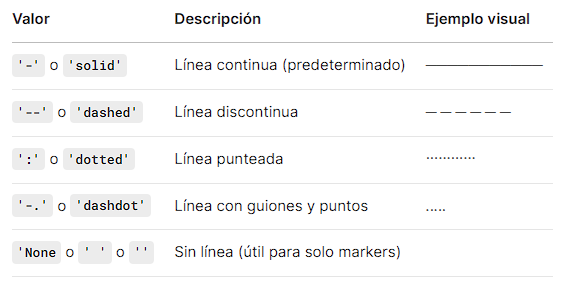

### **Marcadores de Puntos: marker**

Controla los símbolos que marcan los puntos de datos en gráficos de dispersión o líneas. Los valores disponibles son:

Marcadores básicos:

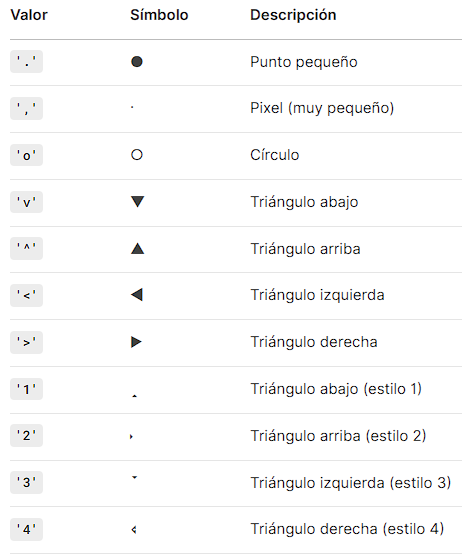

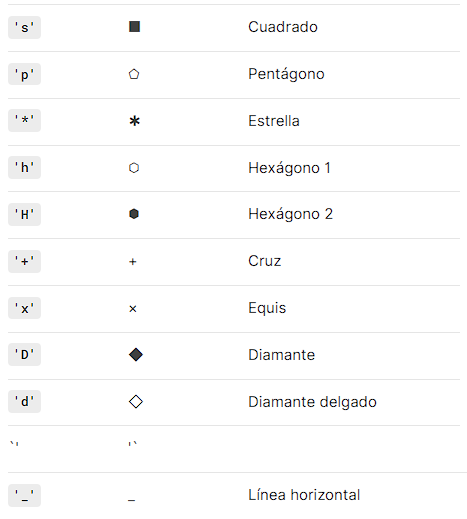

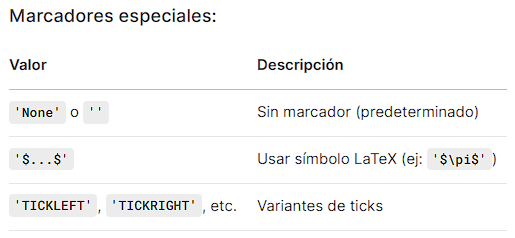

### **Categorías Principales de Colormaps: cmap**

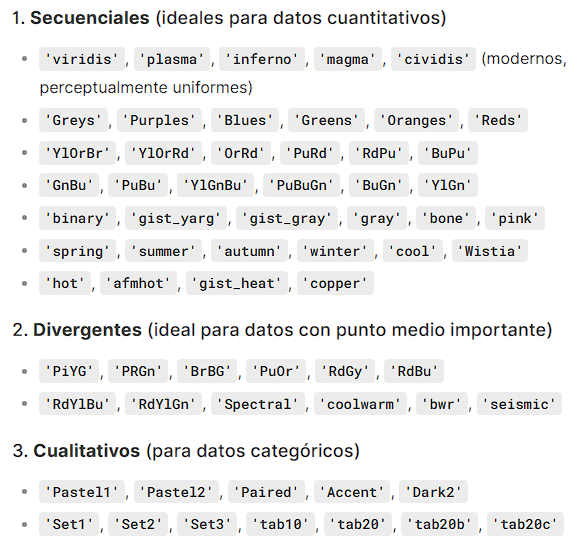

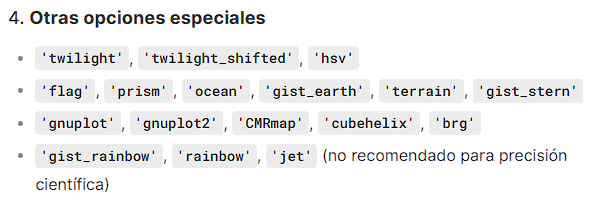

Para invertir cualquier colormap, añade '_r' al nombre

### **GRÁFICOS DE DISTRIBUCIÓN**

### **Gráfico de Caja y Bigotes (Boxplot)**

Un boxplot (o diagrama de caja y bigotes) es una herramienta visual que resume la distribución de un conjunto de datos mediante cinco estadísticos principales, identificando tendencia central, dispersión y valores atípicos.

**📌 Partes de un Boxplot**

**1. Línea central en la caja (Mediana - Q2)**

*  **Qué es:** Valor que divide los datos en dos partes iguales (50% de los datos están por encima y 50% por debajo).
*  **Interpretación:**
  *  Si la mediana está cerca del centro de la caja → **Distribución simétrica**.
  *  Si está más cerca de Q1 o Q3 → **Distribución asimétrica** (sesgada a izquierda o derecha).

**2. Caja (IQR - Rango Intercuartílico)**

*  **Límites:**
  *  **Q1 (Primer cuartil):** 25% de los datos están por debajo de este valor.
  *  **Q3 (Tercer cuartil):** 75% de los datos están por debajo.
*  **Ancho de la caja (IQR = Q3 - Q1):** Mide la dispersión del 50% central de los datos.
  *  IQR grande → **Alta variabilidad**.
  *  IQR pequeño → **Datos concentrados**.

**3. Bigotes (Whiskers)**

*  **Límites:**
  *  **Bigote superior:** mín(Q3 + 1.5 * IQR, valor más grande no atípico).
  *  **Bigote inferior:** máx(Q1 - 1.5 * IQR, valor más pequeño no atípico).
*  **Interpretación:**
  *  Cubren el rango esperado de datos "normales" (no atípicos).

**4. Valores Atípicos (Outliers)**

* **Qué son:** Puntos fuera de los bigotes
>(< Q1 - 1.5 * IQR) o (> Q3 + 1.5 * IQR)
*  **Interpretación:**
  *  Pueden ser errores de medición, eventos raros o datos genuinamente extremos.

**5. Notches (Muescas - Opcional)**

* **Qué son:** Pequeñas muescas en la caja que representan el **intervalo de confianza (IC) de la mediana** (95% IC).

* **Interpretación:**

  * Si los notches de dos boxplots no se superponen → Medianas son estadísticamente diferentes.

**📌 Claves para Analizar un Boxplot**

**Sesgo (Asimetría):**
*  **Sesgo a la derecha:** Mediana más cerca de Q1 → Cola larga a la derecha.
*  **Sesgo a la izquierda:** Mediana más cerca de Q3 → Cola larga a la izquierda.

**Dispersión:**
* Bigotes largos → Datos más dispersos.
* Caja estrecha → Datos concentrados.

**Comparación entre grupos:**
* Si tienes múltiples boxplots (ej: por categorías), compara medianas y IQRs para identificar diferencias.

**📊 Casos Especiales**

**📌 Boxplot sin bigotes superiores/inferiores**
*  Ocurre cuando no hay datos fuera de
>(Q1 - 1.5 * IQR) o (Q3 + 1.5 * IQR)

**📌 Boxplot con muchos Outliers**
*  Sugiere que la distribución tiene colas pesadas o errores en los datos.

**Un boxplot permite identificar rápidamente:**

>✅ Tendencia central (mediana).

>✅ Dispersión (IQR y bigotes).

>✅ Asimetría (posición de la mediana).

>✅ Outliers (datos anómalos).

In [ ]:
plt.figure(figsize=(3, 4))  # Tamaño del gráfico

plt.boxplot(
    df['Presión Académica'],
    vert=True,          # Orientación vertical (False para horizontal)
    patch_artist=True,  # Relleno de la caja
    widths=0.7,           # Ancho de la caja
    boxprops=dict(facecolor='blue', edgecolor='black', linewidth=2, alpha=0.2), # Personaliza la caja
    medianprops=dict(color='red', linewidth=3),  # Personaliza la línea de la mediana
    flierprops=dict(marker='o', markerfacecolor='purple', markersize=8, markeredgecolor='purple'),  # Personaliza los outliers (valores atípicos)
    meanprops=dict(marker='+', markerfacecolor='black', markeredgecolor='black'), # Personaliza el marcador de la media (si se muestra con showmeans=True)
    showmeans=True,  # Mostrar u ocultar la media
    showfliers=True,  # Mostrar u ocultar outliers
    notch=True       # Activa la muesca
)

plt.title('Presión \nAcadémica')
plt.show()

In [ ]:
# Matplotlib

fig, axes = plt.subplots(2, 4, figsize=(5, 10))
plt.subplots_adjust(
    wspace=0.5,
    hspace=0.3
)

axes[0, 0].boxplot(
    df['Presión Académica'],
    vert=True,          # Orientación vertical (False para horizontal)
    patch_artist=True,  # Relleno de la caja
    widths=0.7,           # Ancho de la caja
    boxprops=dict(facecolor='blue', edgecolor='black', linewidth=2, alpha=0.2), # Personaliza la caja
    medianprops=dict(color='red', linewidth=3),  # Personaliza la línea de la mediana
    flierprops=dict(marker='o', markerfacecolor='purple', markersize=8, markeredgecolor='purple'),  # Personaliza los outliers (valores atípicos)
    meanprops=dict(marker='+', markerfacecolor='black', markeredgecolor='black'), # Personaliza el marcador de la media (si se muestra con showmeans=True)
    showmeans=True,  # Mostrar u ocultar la media
    showfliers=True,  # Mostrar u ocultar outliers
    notch=True       # Activa la muesca
)
axes[0, 1].boxplot(
    df['Satisfacción con el Estudio'],
    vert=True,
    patch_artist=True,
    widths=0.7,
    boxprops=dict(facecolor='blue', edgecolor='black', linewidth=2, alpha=0.2),
    medianprops=dict(color='red', linewidth=3),
    flierprops=dict(marker='o', markerfacecolor='purple', markersize=8, markeredgecolor='purple'),
    meanprops=dict(marker='+', markerfacecolor='black', markeredgecolor='black'),
    showmeans=True,
    showfliers=True,
    notch=True
)
axes[0, 2].boxplot(
    df['Promedio Calificaciones Acumulativo'],
    vert=True,
    patch_artist=True,
    widths=0.7,
    boxprops=dict(facecolor='blue', edgecolor='black', linewidth=2, alpha=0.2),
    medianprops=dict(color='red', linewidth=3),
    flierprops=dict(marker='o', markerfacecolor='purple', markersize=8, markeredgecolor='purple'),
    meanprops=dict(marker='+', markerfacecolor='black', markeredgecolor='black'),
    showmeans=True,
    showfliers=True
)
axes[0, 3].boxplot(
    df['Edad'],
    vert=True,
    patch_artist=True,
    widths=0.7,
    boxprops=dict(facecolor='blue', edgecolor='black', linewidth=2, alpha=0.2),
    medianprops=dict(color='red', linewidth=3),
    flierprops=dict(marker='o', markerfacecolor='purple', markersize=8, markeredgecolor='purple'),
    meanprops=dict(marker='+', markerfacecolor='black', markeredgecolor='black'),
    showmeans=True,
    showfliers=True
)
axes[1, 0].boxplot(
    df['Presión Laboral'],
    vert=True,
    patch_artist=True,
    widths=0.7,
    boxprops=dict(facecolor='blue', edgecolor='black', linewidth=2, alpha=0.2),
    medianprops=dict(color='red', linewidth=3),
    flierprops=dict(marker='o', markerfacecolor='purple', markersize=8, markeredgecolor='purple'),
    meanprops=dict(marker='+', markerfacecolor='black', markeredgecolor='black'),
    showmeans=True,
    showfliers=True
)
axes[1, 1].boxplot(
    df['Satisfacción Laboral'],
    vert=True,
    patch_artist=True,
    widths=0.7,
    boxprops=dict(facecolor='blue', edgecolor='black', linewidth=2, alpha=0.2),
    medianprops=dict(color='red', linewidth=3),
    flierprops=dict(marker='o', markerfacecolor='purple', markersize=8, markeredgecolor='purple'),
    meanprops=dict(marker='+', markerfacecolor='black', markeredgecolor='black'),
    showmeans=True,
    showfliers=True
)
axes[1, 2].boxplot(
    df['Horas de Trabajo'],
    vert=True,
    patch_artist=True,
    widths=0.7,
    boxprops=dict(facecolor='blue', edgecolor='black', linewidth=2, alpha=0.2),
    medianprops=dict(color='red', linewidth=3),
    flierprops=dict(marker='o', markerfacecolor='purple', markersize=8, markeredgecolor='purple'),
    meanprops=dict(marker='+', markerfacecolor='black', markeredgecolor='black'),
    showmeans=True,
    showfliers=True
)

# Títulos
axes[0, 0].set_title('Presión \nAcadémica')
axes[0, 1].set_title('Satisfacción \ncon el Estudio')
axes[0, 2].set_title('Promedio \nCalificaciones \nAcumulativo')
axes[0, 3].set_title('Edad')
axes[1, 0].set_title('Presión \nLaboral')
axes[1, 1].set_title('Satisfacción \nLaboral')
axes[1, 2].set_title('Horas de \nTrabajo')

#axes[0, 0].grid(axis='y')
plt.tight_layout()
plt.show()

In [ ]:
# Seaborn

fig, axes = plt.subplots(2, 4, figsize=(5, 10))
plt.subplots_adjust(
    wspace=0.5,
    hspace=0.3
)

sns.boxplot(
    data=df,
    y='Presión Académica',
    color='lightblue',
    width=0.5,
    linewidth=1.5,    # Grosor de las líneas
    fliersize=4,      # Tamaño de los outliers
    ax=axes[0, 0],     # Usar ax=axes[0,0]
    notch=True         # Activa la muesca
)
sns.boxplot(
    data=df,
    y='Satisfacción con el Estudio',
    color='lightblue',
    width=0.5,
    linewidth=1.5,    # Grosor de las líneas
    fliersize=4,      # Tamaño de los outliers
    ax=axes[0, 1]     # Usar ax=axes[0,0]
)
sns.boxplot(
    data=df,
    y='Promedio Calificaciones Acumulativo',
    color='lightblue',
    width=0.5,
    linewidth=1.5,    # Grosor de las líneas
    fliersize=4,      # Tamaño de los outliers
    ax=axes[0, 2]     # Usar ax=axes[0,0]
)
sns.boxplot(
    data=df,
    y='Edad',
    color='lightblue',
    width=0.5,
    linewidth=1.5,    # Grosor de las líneas
    fliersize=4,      # Tamaño de los outliers
    ax=axes[0, 3]     # Usar ax=axes[0,0]
)
sns.boxplot(
    data=df,
    y='Presión Laboral',
    color='lightblue',
    width=0.5,
    linewidth=1.5,    # Grosor de las líneas
    fliersize=4,      # Tamaño de los outliers
    ax=axes[1, 0]     # Usar ax=axes[0,0]
)
sns.boxplot(
    data=df,
    y='Satisfacción Laboral',
    color='lightblue',
    width=0.5,
    linewidth=1.5,    # Grosor de las líneas
    fliersize=4,      # Tamaño de los outliers
    ax=axes[1, 1]     # Usar ax=axes[0,0]
)
sns.boxplot(
    data=df,
    y='Horas de Trabajo',
    color='lightblue',
    width=0.5,
    linewidth=1.5,    # Grosor de las líneas
    fliersize=4,      # Tamaño de los outliers
    ax=axes[1, 2]     # Usar ax=axes[0,0]
)

plt.tight_layout()
plt.show()

### **Gráfico de Violín (Distribución + Densidad)**

**Propósito:** Un violinplot es una herramienta de visualización que combina características de un boxplot con una estimación de la densidad de probabilidad, permitiéndote entender mejor la distribución de tus datos.

**Sirve para:**
*  Visualizar distribuciones: Muestra cómo se distribuyen los datos
*  Comparar grupos: Permite comparar distribuciones entre categorías
*  Identificar características: Revela modas, dispersión y asimetría
*  Detectar outliers: Ayuda a identificar valores atípicos

**Interpretación:**
*  **Distribución general:**
  *  La forma del violín te muestra cómo se distribuyen los datos en y
  *  Si es simétrico: distribución normal
  *  Si tiene un pico a la izquierda: sesgo positivo (más datos bajos)
  *  Si tiene un pico a la derecha: sesgo negativo (más datos altos)
*  **Forma/ancho:**
  *  Las partes más anchas indican mayor concentración de datos
  *  Las partes estrechas indican menos datos en ese rango
*  **Líneas internas:**
  *  Si se usa inner='quartile' se verán tres líneas que representan:
    *  Q1 (25% de los datos están por debajo)
    *  Q2 (mediana, 50%)
    *  Q3 (75%)
*  **Extremos:**
  *  Los puntos más altos/bajos muestran el rango de los datos
  *  La "cola" muestra cómo se dispersan los valores extremos

**Uso:**
*  Ideal para comparar distribuciones entre categorías
*  Útil cuando quieres más detalle que un boxplot tradicional
*  Bueno para mostrar distribuciones multimodales
*  Recomendado para conjuntos de datos medianos/grandes

Esto es en Seaborn, Matplotlib no lo soporta nativamente.

In [ ]:
# Seaborn

plt.figure(figsize=(8, 6))
sns.violinplot(
    data=df,
    x='Género',   # Variable para el eje horizontal (categórica)
    y='Promedio Calificaciones Acumulativo',   # Variable para el eje vertical (numérica)
    hue='Depresión',    # Variable para subdividir los violines por color
    order=['Masculino', 'Femenino'],   # Orden de las categorías en el eje x
    #hue_order=['Masculino', 'Femenino'],   # Orden de las subcategorías dentro de cada violín
    bw_method='scott',    # Método de suavizado ('scott': Ancho de banda basado en desviación estándar, 'silverman': Fórmula más robusta para ancho de banda, float: Valor numérico específico)
    inner='quartile',    # 'box': Muestra un boxplot interno, 'quartile': Muestra los cuartiles (Q1, Q2, Q3), 'stick': Muestra observaciones individuales, None: Solo muestra el violín
    split=True,    # Divide los violines para comparación directa. Requiere exactamente dos niveles en la variable hue
    density_norm='count',   # 'area': Todos tienen igual área, 'count': El ancho refleja el número de observaciones, 'width': Todos tienen igual ancho
    #scale_hue=False,   # True: Escala independiente por subgrupo, False: Misma escala
    palette='coolwarm',
    saturation=0.8,      # Intensidad del color (0 a 1):
    width=0.9,
    linewidth=1.5,
    edgecolor='black',
    cut=0       # 0: Limita el violín al rango de los datos, 1 (default): Extiende un poco más allá del rango
)

plt.title('Depresión por Promedios y Género', pad=20)
plt.legend(title='Depresión', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### **Histograma (Distribución de Frecuencias)**

**Propósito:** Un histograma es una de las herramientas más útiles para analizar la distribución de datos continuos o intervalos discretos. A diferencia de un gráfico de barras (que muestra categorías), el histograma revela cómo se distribuyen los valores numéricos en rangos o "bins".

**Sirve para:**
*  **Visualizar distribuciones:** Entender cómo se agrupan los datos (normal, sesgada, uniforme).
*  **Identificar patrones:** Moda, dispersión, valores atípicos.
*  **Analizar continuidad:** Para variables numéricas (edad, precios, tiempo).
*  **Detectar anomalías:** Picos inesperados o vacíos en la distribución.

**Partes clave de un histograma:**
*  **Eje X (horizontal):** Rangos de valores (ej: 0-10, 10-20, etc.).
*  **Eje Y (vertical):** Frecuencia (cuántos datos caen en cada rango).
*  **Barras adyacentes:** Sin espacios entre ellas (indica continuidad).
*  **Bins (contenedores):** Intervalos en los que se agrupan los datos.

**Interpretación:**
*  **Forma de la distribución:**
  *  Distribución normal (campana de Gauss):
    *  Forma simétrica.
    *  Pico en el centro.
  *  Sesgada a la derecha (positiva):
    *  Cola larga hacia la derecha.
  *  Sesgada a la izquierda (negativa):
    *  Cola larga hacia la izquierda.
  *  Bimodal/Multimodal:
    *  Dos o más picos.

*  **Dispersión**
  *  Amplia: Datos muy esparcidos (alta varianza).
  *  Estrecha: Datos concentrados (baja varianza).
*  **Valores atípicos**
  *  Barras aisladas en extremos (ej: un bin con muy pocos datos lejos del resto).
*  **Cortes o vacíos**
  *  Rangos sin datos (ej: precios de productos que evitan ciertos valores).

**Errores comunes:**
*  **Elegir mal el número de bins:**
  *  **Pocos bins:** Oculta patrones.
  *  **Demasiados bins:** Crece el "ruido".
  *  **Regla práctica:** Usar la raíz cuadrada del número de datos `(np.sqrt(len(datos)))`.
*  **Ignorar el sesgo:** Confundir una distribución sesgada con normal.
*  **Comparar histogramas con escalas distintas:** Siempre usar mismos ejes para comparar.

**NO usar:**
*  Para datos categóricos (usar gráfico de barras).
*  Para pocos datos (<30 observaciones).
*  Para comparar grupos (mejor: histogramas múltiples o boxplots).


In [ ]:
# Matplotlib

plt.hist(
    df['Horas de Trabajo'],
    bins=6,            # Número de barras (o lista con bordes)
    color='skyblue',   # Color de las barras
    edgecolor='black', # Borde de las barras
    alpha=0.7,         # Transparencia (0 a 1)
    density=False     # Si True, muestra densidad en lugar de frecuencia
)

plt.title('Distribución de Horas de Trabajo')
plt.xlabel('Valores')
plt.ylabel('Frecuencia (Estudiantes)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

In [ ]:
# Seaborn
sns.histplot(
    data=df,
    x='Horas de Trabajo',
    bins=6,
    kde=True,       # Si True, añade curva de densidad. stat='density'
    color='blue',
    stat='count'    # 'count': 	Mostrar números absolutos, 'frequency': Comparar proporciones sin normalizar por bin width,
                    # 'density': Cuando usas kde=True o comparas distribuciones con distintos bins, 'probability': Porcentajes directos
)
plt.title('Distribución de Horas de Trabajo')
plt.xlabel('Valores')
plt.ylabel('Frecuencia (Estudiantes)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

### **GRÁFICOS DE COMPOSICIÓN**

### **Gráfico de Torta (Pie Chart)**

**Propósito:** Un gráfico de torta es una visualización circular que muestra la composición porcentual de un todo dividido en categorías. Es ideal para representar proporciones y porcentajes.

**Sirve para:**
*  Mostrar proporciones: Visualizar cómo se divide un todo en partes.
*  Comparar categorías: Identificar rápidamente las partes más grandes o pequeñas.
*  Destacar una fracción: Resaltar un segmento específico.
*  Comunicar datos simples: Cuando tienes pocas categorías (ideal ≤5-6).

**Interpretación:**

*  **Identifica las categorías**
  *  ¿Qué representa cada porción? .
*  **Analiza los tamaños relativos**
  *  La porción más grande = categoría dominante.
  *  La más pequeña = categoría menos relevante.
*  **Revisa porcentajes o valores**
  *  Si incluye porcentajes, verifica cómo contribuye cada parte al total.
*  **Busca patrones**
  *  ¿Hay una categoría que domina? .
  *  ¿Las categorías están balanceadas?

**Errores comunes al usar gráficos de torta:**
*  Demasiadas categorías (>6): Se vuelve ilegible.
>Solución: Agrupar categorías pequeñas en "Otros".
*  Porciones muy similares: Difícil comparar.
>Solución: Usar gráfico de barras horizontales.
*  Falta de porcentajes/valores: Sin números, es solo una aproximación visual.
*  Colores no contrastantes: Dificulta diferenciar categorías.


Seaborn no tiene una función nativa para gráficos de torta.

In [ ]:
# Datos

categorias = df['Hábitos Alimenticios'].value_counts()

plt.pie(
    categorias,
    labels=categorias.index,  # Etiquetas para cada segmento
    colors=['#ff9999', '#66b3ff', '#99ff99', '#ffcc99'], # Colores personalizados
    autopct='%1.1f%%',      # Porcentajes con 1 decimal
    startangle=90,          # Ángulo inicial (90° = empieza en la parte superior)
    shadow=True,            # Efecto de sombra
    explode=(0.1, 0, 0, 0)  # Separar/Destacar un segmento (ej: 'B')
)
plt.title('Hábitos Alimenticios')
plt.axis('equal')  # Para que sea un círculo perfecto
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.show()

### **GRÁFICOS DE COMPARACIÓN**

### **Gráfico de Barras**

**Propósito:** Un gráfico de barras es una de las visualizaciones más comunes y efectivas para comparar categorías o mostrar la distribución de datos discretos.

**Sirve para:**
*  **Comparar categorías:** Muestra diferencias entre grupos.
*  **Mostrar frecuencias:** Cuántas veces ocurre algo.
*  **Identificar tendencias:** Patrones entre grupos ordenados.
*  **Destacar máximos/mínimos:** Revela qué categorías sobresalen.

**Partes clave de un gráfico de barras**
*  **Barras verticales/horizontales:**
  *  Altura/longitud = valor numérico.
  *  Ancho = generalmente fijo (puede variar en gráficos especiales).
*  **Eje X (categórico):**
  *  Contiene las categorías.
*  **Eje Y (numérico):**
  *  Escala de valores.
*  **Títulos y etiquetas:**
  *  Deben ser claros para entender qué se compara.

**Interpretación**
*  **Identifica las variables:**
  *  ¿Qué se compara?
*  **Observa la altura/longitud de las barras:**
  *  La más alta = valor máximo.
  *  La más baja = valor mínimo.
*  **Busca patrones:**
  *  ¿Hay categorías que dominan?
  *  ¿Hay una tendencia ascendente/descendente si están ordenadas?
*  **Compara diferencias:**
  *  ¿Cuánto más grande es A respecto a B?
*  **Revisa escalas:**
  *  ¡Cuidado con ejes que no empiezan en 0! Pueden exagerar diferencias.

**Errores comunes al interpretar**
*  **Ignorar el orden de las barras:**
  *  Siempre ordena por valor si buscas tendencias.
*  **Malinterpretar proporciones:**
  *  Si el eje Y no empieza en 0, las diferencias parecen mayores.
*  **Sobrecargar el gráfico:**
  *  Con +15 categorías, considera un gráfico horizontal o filtrar datos.

**NO usarlo cuando:**
*  Para distribuciones continuas (se usa histogramas).
*  Para series temporales (mejor líneas).
*  Cuando hay demasiadas categorías (>20).

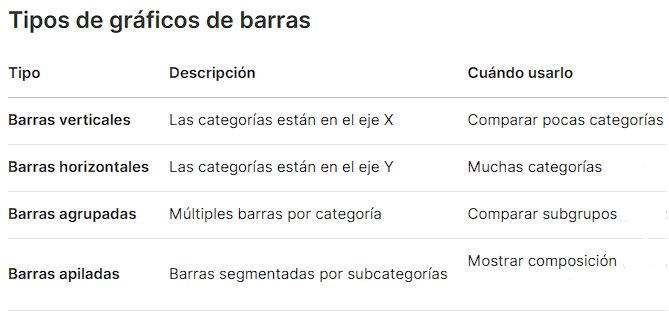

Para las barras horizontales usa `plt.barh(categories, values, ...)`. En Seaborn sólo invierte el x y el y.

Para las barras agrupadas se usan varios `plt.bar()` con un bloque de carácterísticas único `plt.show()` al final, así como las siguientes instrucciones:
```
bar_width = 0.5  # bar_width * N.barras agrupadas = 1  # Define el ancho de cada barra individual dentro de un grupo
index = range(len(categories))  # Crea una secuencia de números enteros que servirá como la posición en el eje X para cada grupo
                                # de barras equivalente a [0, 1, 2, 3]
plt.bar(index - bar_width/2, values_group1, bar_width, label='Grupo 1')  # Barras a la izquierda. "index - bar_width/2" calcula
                                    # la posición X para el centro de cada barra. Restarle bar_width/2 desplaza estas barras
                                    # hacia la izquierda del punto index, para que queden "agrupadas" con las del otro conjunto.
plt.bar(index + bar_width/2, values_group2, bar_width, label='Grupo 2')  # Barras a la derecha
```
En Seaborn, el parámetro hue debe ser `hue='variable'`, y x tomar otro valor.

Para las barras anidadas o apiladas se colocan varias plt.bar() y a la que quedará debajo de la otra se le añade el parámetro `bottom=nombre_variable`.

In [ ]:
# Matplotlib
categorias = frecuencia_genero

plt.bar(
    categorias.index,  # Usar .index para las etiquetas de la Serie
    categorias.values, # Usar .values para los valores de la Serie
    color='blue',
    width=0.6,
    edgecolor='black',
    label='Categorías'
)
plt.title('Comparación de Frecuencias por Género')
plt.xlabel('Género')
plt.ylabel('Frecuencia')
plt.legend(bbox_to_anchor=(1, 1), loc='upper left')
plt.xticks(rotation=0)   # Rotas las etiquetas
plt.grid(axis='y', linestyle='--', alpha=0.8)
plt.show()

In [ ]:
# Seaborn

sns.barplot(
    x=categorias.index,  # Usar el índice de la Series para el eje X
    y=categorias.values, # Usar los valores de la Series para el eje Y
    hue=None,
    estimator='count',       # 'median', 'sum', etc.
    errorbar=('ci', 95),    # Intervalo de confianza (None para omitir)
    capsize=0.1             # Tamaño de las líneas de error
)
plt.title('Comparación de Frecuencias por Género')
plt.xlabel('Género')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)  # Rotas las etiquetas
plt.show()

### **GRÁFICOS DE TENDENCIA / TEMPORAL**

### **Gráfico de Línea (Line Plot)**

**Propósito:** Un gráfico de línea (o line plot) es una representación visual que conecta puntos de datos individuales con segmentos rectos, mostrando la evolución de una variable a lo largo de un eje continuo (como tiempo o distancia).

**Sirve para:**
*  Mostrar tendencias temporales.
*  Comparar múltiples series.
*  Identificar patrones: Estacionalidad, picos, valles o cambios abruptos.
*  Visualizar relaciones continuas.

**Partes clave de un gráfico de línea**
*  **Eje X (horizontal):** Variable independiente.
*  **Eje Y (vertical):** Variable dependiente.
*  **Líneas:** Conectan puntos de datos en orden secuencial.
*  **Marcadores:** Puntos que representan valores individuales (opcionales).
*  **Leyenda:** Explica series cuando hay múltiples líneas.
*  **Varias líneas:** Se colocan varios `.plot()` para un mismo `.show()`.

**Interpretación:**
*  **Dirección de la línea**
  *  **Ascendente:** Aumento en la variable Y al avanzar en X.
  *  **Descendente:** Disminución en Y.
  *  **Estable:** Sin cambios significativos.
*  **Pendiente (inclinación)**
  *  **Pendiente pronunciada:** Cambio rápido.
  *  **Pendiente suave:** Cambio gradual.
*  **Patrones recurrentes**
  *  **Estacionalidad:** Repetición de patrones en intervalos regulares.
  *  **Ciclos:** Fluctuaciones no periódicas.
*  **Puntos clave**
  *  **Máximos y mínimos:** Identificar valores pico o valles.
  * **Puntos de inflexión:** Donde la tendencia cambia.
*  **Comparación entre líneas**
  *  **Cruces:** Cuando una serie supera a otra.
  *  **Divergencias:** Diferencias crecientes/reductivas entre series.

**Errores comunes:**
*  **Eje X no ordenado:** Si los datos no son secuenciales, la línea engaña.
*  **Demasiadas líneas:** >5 series dificultan la lectura (usar facetas o interactividad).
*  **Escalas inapropiadas**.

**NO usarlo:**
*  Datos categóricos no ordenados (mejor: gráfico de barras).
*  Muy pocos puntos (<4, mejor: diagrama de puntos).
*  Variables discretas.

In [ ]:
# Matplotlib

meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun']
ventas_producto = [120, 150, 180, 90, 110, 130]

plt.plot(
    meses,                   # x
    ventas_producto,         # y
    color='purple',          # Color de la línea
    linestyle='--',          # Estilo de línea ('-', '--', ':', '-.')
    linewidth=2,             # Ancho de la línea
    marker='o',              # Marcadores (ej: 'o', 's', '^')
    markersize=5,            # Tamaño de los marcadores
    label='Ventas'           # Etiqueta para la leyenda
)

plt.title('Gráfico de Línea en Matplotlib')
plt.xlabel('Eje X')
plt.ylabel('Eje Y')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Seaborn

data = pd.DataFrame({
    'Año': [2010, 2011, 2012, 2013, 2014, 2015, 2016],
    'Ventas': [120, 145, 160, 175, 190, 210, 230]
})

plt.figure(figsize=(6, 4))  # Tamaño del gráfico

sns.lineplot(
    data=data,                # DataFrame de entrada
    x='Año',                 # Variable para el eje X (debe ser numérica o categórica ordenada)
    y='Ventas',            # Variable para el eje Y
    #hue='',                # Opcional: Color por variable (útil para múltiples líneas)
    #style='',              # Opcional: Estilo de línea por variable
    markers=True,            # Mostrar marcadores en los puntos de datos
    dashes=True,            # Líneas sólidas (sin segmentos)
    #palette='viridis',       # Mapa de colores si hue está activo
    linewidth=2.5,           # Grosor de la línea
    marker='o',              # Tipo de marcador ('o', 's', 'D', etc.)
    markersize=8,            # Tamaño de los marcadores
    alpha=0.8,              # Transparencia (0 a 1)
    estimator=None,       # Función para agregar datos 'mean', 'median', None para datos crudos)
    errorbar='sd',                # Intervalo de confianza: 'sd': Desviación estándar, 95:Intervalo del 95%, None:Sin sombreado
    legend='auto'           # Leyenda automática
)

plt.title('Evolución de Ventas', fontsize=14)
plt.xlabel('Año', fontsize=12)
plt.ylabel('Ventas (unidades)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()  # Eliminar bordes superfluos

plt.tight_layout()
plt.show()